# Part 1: Data Preparation and Exploratory Analysis

## The Kulturkampf and Catholic fertility in Prussia

**Research question.** Did Bismarck's anti-Catholic Kulturkampf legislation (1872–1878) affect the Catholic–Protestant fertility differential in Prussian counties?

This first notebook builds the analysis panel from the raw Galloway Prussia Database (1862–1890), merges in the iPEHD 1871 cross-sectional controls, deduplicates the panel key, nullifies extreme rate observations driven by 1868 county-boundary reforms, and explores the raw distributions and trends. Subsequent notebooks (02–04) layer econometric specifications, mechanisms, and identification strategies on top.

> **Headline preview.** The most robust empirical finding across every spec we run is on the *marriage rate*, not the crude birth rate. The fertility effect, while striking under 2SLS, is not robust to pre-trends adjustment. The strongest heterogeneity is along the Polish/German Catholic axis, not the Catholic/Protestant axis. This notebook surfaces the patterns that motivate that conclusion.

> ### Data convention (post-revision)
>
> This notebook uses the **mid-year population denominator** for all rate variables (`cbr`, `legitimate_br`, `illegitimate_br`, `marriage_rate`, `inmig_rate`, `outmig_rate`, `net_mig_rate`) — the standard demographic convention, matching **Galloway, Hammel & Lee (1994), *Population Studies* 48: 135–158**. Mid-year population is constructed by linearly interpolating between consecutive December census anchors and evaluating at July 1 of each calendar year (see [`compute_midyear_population()`](../src/data/load_data.py)). The Galloway carry-forward variants (`cbr_carryforward`, etc.) are reported only as a single robustness row in [`outputs/tables/baseline_did.tex`](../outputs/tables/baseline_did.tex). The `ln_pop` control also uses `Poptot_midyear` so the regression does not mix conventions.
>
> The panel additionally includes the **Princeton EFP / Coale–Watkins indices** (`I_f`, `I_g`, `I_h`, `gmfr`) computed via [`coale_indices.compute_coale_indices()`](../src/analysis/coale_indices.py). $I_g$ (Coale marital fertility, Hutterite-normalised) is the headline outcome in Galloway, Hammel & Lee (1994); we report it alongside CBR and marriage rate. The static-1871 `gfr_static_1871` column is **deprecated** and superseded by $I_g$ for marital-fertility analysis.
>
> See [`DATA_APPENDIX.md`](../DATA_APPENDIX.md) §6.2–6.5 for the full variable dictionary.

## 1. Setup

Load paths, libraries, and the project's `src.data` pipeline.

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_RAW = project_root / "data" / "raw" / "galloway_data"
DATA_PROCESSED = project_root / "data" / "processed"
OUTPUTS = project_root / "outputs" / "figures"
OUTPUTS.mkdir(exist_ok=True, parents=True)
TABLES = project_root / "outputs" / "tables"
TABLES.mkdir(exist_ok=True, parents=True)

print("Setup complete.")
print(f"Figures -> {OUTPUTS}")
print(f"Tables  -> {TABLES}")

from src.data.build_dataset import build_analysis_panel
from src.visualization.plots import (
    plot_cath_distribution, plot_fertility_trends,
)

Setup complete.
Figures -> C:\Users\Anton\Demography\.claude\worktrees\inspiring-elgamal-4e8e7e\exam_project2\outputs\figures
Tables  -> C:\Users\Anton\Demography\.claude\worktrees\inspiring-elgamal-4e8e7e\exam_project2\outputs\tables


## 2. Build the analysis panel

`build_analysis_panel` performs the full data-preparation pipeline:

1. Load REL1871 to get each county's time-invariant Catholic share.
2. Load and harmonise the VIT vital-registration files (1862–1890).
3. Interpolate missing population from intermediate POP census files.
4. Merge religion + vital data, construct outcome variables (CBR, legitimate BR, illegitimacy ratio, marriage rate, etc.).
5. Construct treatment variables (`post_kulturkampf`, `high_cath`, `cath_share_x_post`, `treat_x_post`).
6. Nullify rate columns where `cbr_flag` triggers (extreme CBR > 70 or < 15) — these are typically county-boundary-reform artefacts (e.g. Beuthen 1869–71).
7. Drop duplicate `(Code, Year)` rows (the source files contain one mislabelled Iserlohn 1866 row).
8. Merge in iPEHD cross-sectional controls (`f_jew`, `f_urban`, `school1517`, `kmwittenberg`, ...) for the heterogeneity and IV strategies in notebooks 03–04.

In [2]:
panel = build_analysis_panel(
    data_dir=DATA_RAW,
    year_start=1862,
    year_end=1890,
    save=True,
)
print(f"Panel: {len(panel):,} obs, {panel['Code'].nunique()} counties, "
      f"years {int(panel['Year'].min())}–{int(panel['Year'].max())}")
print(f"Columns: {len(panel.columns)} total\n")
panel.head(5)

6 observations with extreme CBR (>70 or <15 per 1000); rate columns set to NaN


9 observations with extreme gfr_static_1871 (>400); set to NaN


Dropping duplicate (Code, Year) rows (keeping first): [{'Code': 545, 'Kreis': 'ISERLOHN', 'Year': 1866}]


Dropped 1 duplicate row(s)


Step 1 — Direct code match: 264 candidates -> 61 valid (dropped 203)
Step 2 — Manual crosswalk: 44 candidates -> 43 valid (dropped 1)
Step 3 — Name match: 251 candidates -> 248 valid (dropped 3)

Final crosswalk: 352 county mappings (out of 393 Galloway Type-0 counties)
iPEHD merge complete:
  Crosswalk: 352 county mappings
  Counties with iPEHD data: 351 / 392
  Observations with iPEHD data: 9645 / 10784
  Variables added: ['f_prot', 'f_cath', 'f_jew', 'f_urban', 'f_young', 'f_fem', 'f_ortsgeb', 'f_pruss', 'hhsize', 'lnpop', 'pop', 'gpop', 'f_blind', 'f_deaf', 'f_dumb', 'kmwittenberg', 'f_miss', 'school1517']

  Validation: corr(Galloway cath_share, iPEHD f_cath) = 0.9998
  OK Crosswalk validated — religion shares match closely.


Panel: 10,783 obs, 392 counties, years 1862–1890
Columns: 90 total



,Code,Rb,Kreis,Type,Year,Poptot,Birtot,Birlegtot,Birbastot,Dthtot,...,age_60p_m_1871,age_60p_f_1871,women_15_49_1871,women_share_15_49_1871,gfr_static_1871,gfr_flag,I_f,I_g,I_h,gmfr
0,1,KON,MEMEL,0.0,1862,53505.000000,1974,1792,182,1531,...,1382,2368,15067,26.925551,131.014801,False,0.369164,0.539202,0.089931,205.059063
1,1,KON,MEMEL,0.0,1863,53505.000000,2056,1886,170,1373,...,1382,2368,15067,26.925551,136.457158,False,0.381268,0.562717,0.083295,214.001929
2,1,KON,MEMEL,0.0,1864,53505.000000,2209,1984,225,1444,...,1382,2368,15067,26.925551,146.611801,False,0.406227,0.587024,0.109325,223.245839
3,1,KON,MEMEL,0.0,1865,54472.666667,2104,1926,178,1378,...,1382,2368,15067,26.925551,139.642928,False,0.381554,0.561962,0.085289,213.714932
4,1,KON,MEMEL,0.0,1866,55440.333333,2017,1841,176,2031,...,1382,2368,15067,26.925551,133.868720,False,0.359345,0.527717,0.082848,200.691350


**Interpretation.** The build pipeline produces ~10,800 county-year observations across 392 counties. Note the warnings emitted during the build:
- 6 observations had extreme CBR under either the mid-year or Galloway carry-forward convention (Beuthen 1869–1871, Tarnowitz 1872, etc.); rate columns are NaN for these rows. An additional 9 observations are flagged on the static-1871 GFR (boundary-reform artefacts where 1872-boundary births are paired with 1871-boundary women aged 15–49). The regression code drops these via standard NaN handling.
- 1 duplicate `(Code, Year)` row (Iserlohn 1866) was dropped.
- The iPEHD merge covers ~90% of Galloway counties; remaining 10% have NaN for iPEHD-derived controls (handled per-regression).

This is a *defended* panel: the previous version of the build silently kept duplicates and out-of-range rates, which contaminated several downstream regressions.

## 3. Descriptive statistics

A first look at means and standard deviations split by treatment group (high- vs low-Catholic, defined at the 50% threshold) and by period (pre/post Kulturkampf). This is the "raw" pattern before any controls.

In [3]:
print("=" * 70)
print("DESCRIPTIVE STATISTICS BY GROUP × PERIOD")
print("=" * 70)

panel["period"] = np.where(panel["Year"] >= 1873, "Post (1873–90)", "Pre (1862–72)")
panel["group"] = np.where(panel["high_cath"] == 1, "High Catholic", "Low Catholic")

for outcome in ("cbr", "legitimate_br", "illegitimacy_ratio", "marriage_rate"):
    print(f"\n--- {outcome} ---")
    summary = (panel.groupby(["group", "period"])[outcome]
                    .agg(["mean", "std", "count"])
                    .round(2))
    print(summary.to_string())

DESCRIPTIVE STATISTICS BY GROUP × PERIOD

--- cbr ---
                               mean   std  count
group         period                            
High Catholic Post (1873–90)  39.81  6.03   2323
              Pre (1862–72)   39.69  6.56   1358
Low Catholic  Post (1873–90)  38.50  4.85   4626
              Pre (1862–72)   38.55  4.99   2470

--- legitimate_br ---
                               mean   std  count
group         period                            
High Catholic Post (1873–90)  37.81  5.63   2323
              Pre (1862–72)   37.50  5.98   1358
Low Catholic  Post (1873–90)  35.12  4.55   4626
              Pre (1862–72)   34.98  4.80   2470

--- illegitimacy_ratio ---
                              mean   std  count
group         period                           
High Catholic Post (1873–90)  4.94  3.29   2323
              Pre (1862–72)   5.35  3.62   1358
Low Catholic  Post (1873–90)  8.75  3.51   4626
              Pre (1862–72)   9.29  3.48   2470

--- marriage_rate 

**Interpretation.** Three things to notice:

1. **Levels.** High-Catholic counties have higher fertility throughout the panel — the Catholic–Protestant fertility gap predates the Kulturkampf and persists. A simple "post vs pre" comparison would conflate this *level* difference with a *change*.
2. **CBR change is small.** CBR for high-Catholic counties barely moves between pre and post; low-Catholic counties move slightly more. The differential change in CBR is ~+0.6 per 1,000 — *positive*, not negative.
3. **Marriage rate falls in both groups, more steeply for high-Catholic.** Pre-Kulturkampf marriage rates were nearly equal across groups; post-Kulturkampf high-Catholic counties drop more.

This already foreshadows the headline finding: marriage rate, not CBR, is where the Kulturkampf bites.

## 4. Distribution of the treatment variable

The Kulturkampf was nationwide, but its localised intensity scales with the Catholic share of a county. Examining the distribution of `cath_share` matters for two reasons: (i) we need enough variation for the continuous-treatment specification, and (ii) the bimodality (or lack of it) tells us whether the binary "HighCath > 50%" specification is hiding a threshold effect.

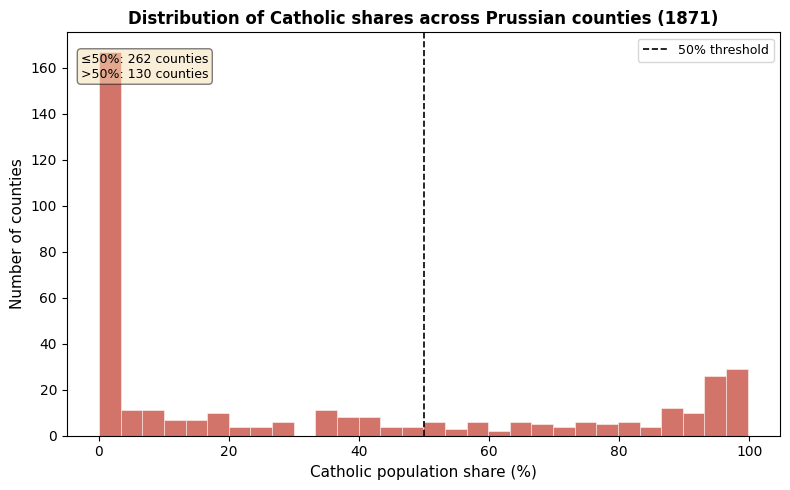


cath_share quartiles: Q1=0.8, Median=14.4, Q3=74.9
Counties >75% Catholic: 95
Counties <25% Catholic: 218


In [4]:
fig, ax = plot_cath_distribution(
    panel, savepath=str(OUTPUTS / "fig1_cath_distribution.png"),
)
plt.show()
print(f"\ncath_share quartiles: "
      f"Q1={panel['cath_share'].quantile(.25):.1f}, "
      f"Median={panel['cath_share'].median():.1f}, "
      f"Q3={panel['cath_share'].quantile(.75):.1f}")
print(f"Counties >75% Catholic: {(panel.drop_duplicates('Code')['cath_share'] > 75).sum()}")
print(f"Counties <25% Catholic: {(panel.drop_duplicates('Code')['cath_share'] < 25).sum()}")

**Interpretation.** The distribution is strongly bimodal: most Prussian counties are either dominantly Protestant ($<$25% Catholic) or dominantly Catholic ($>$75% Catholic), with relatively few in the middle. This bimodality:
- Justifies treating cath\_share as a continuous treatment (real variation across the full range);
- Means the binary "$>$50%" specification implicitly compares two well-separated sub-populations — not a marginal threshold question;
- Motivates the high-vs-low contrast (75% vs 25%) used in the magnitude decomposition (notebook 03).

## 5. Raw fertility and marriage trends over time

Before any fixed-effects estimation, plotting raw means by group is the single most informative diagnostic. *Parallel trends* requires that the high- and low-Catholic groups would have evolved similarly absent the Kulturkampf. We check this visually for each outcome.

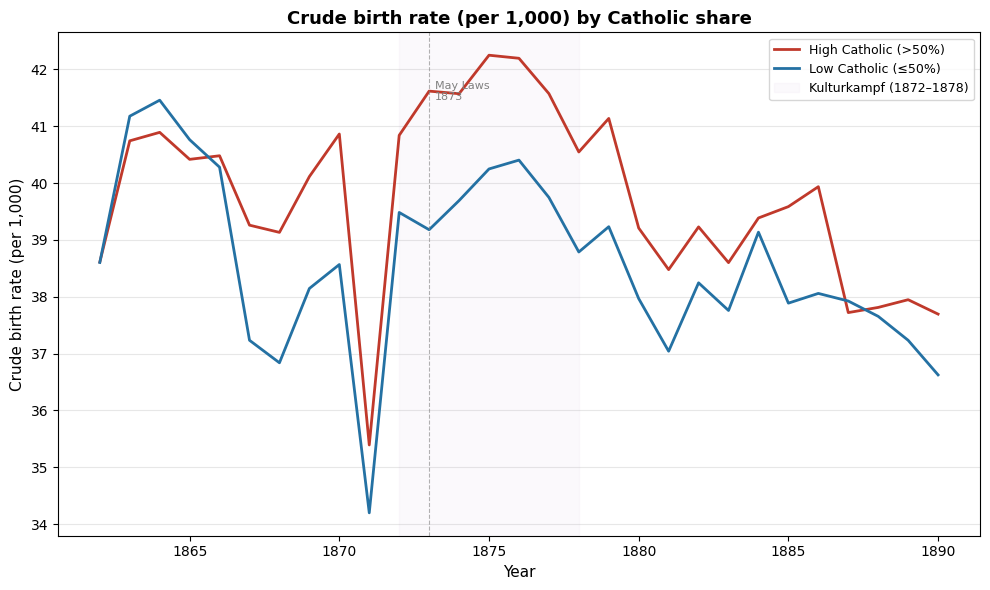

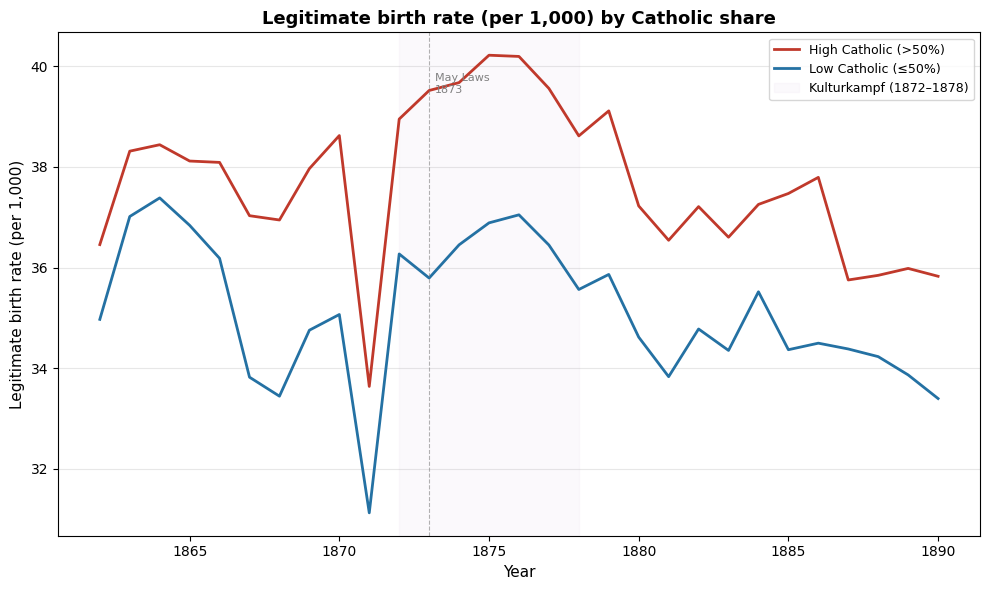

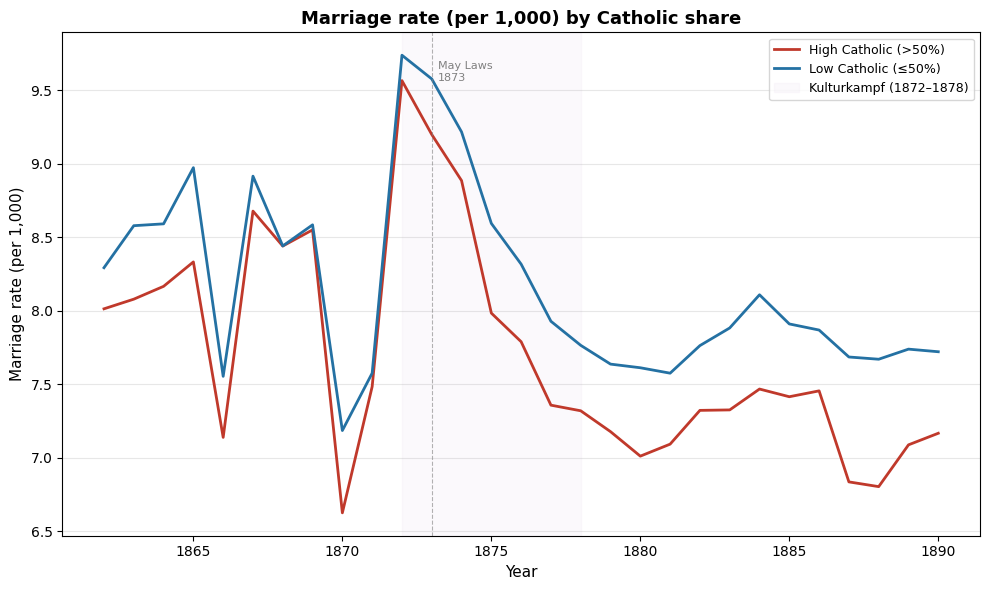

In [5]:
for outcome, ylabel, fname in [
    ("cbr", "Crude birth rate (per 1,000)", "fig2_fertility_trends.png"),
    ("legitimate_br", "Legitimate birth rate (per 1,000)", "fig3_legit_fertility_trends.png"),
    ("marriage_rate", "Marriage rate (per 1,000)", "fig_marriage_trends.png"),
]:
    if outcome in panel.columns and panel[outcome].notna().any():
        fig, ax = plot_fertility_trends(
            panel, outcome=outcome, ylabel=ylabel,
            title=f"{ylabel} by Catholic share",
            savepath=str(OUTPUTS / fname),
        )
        plt.show()

**Interpretation — the parallel-trends puzzle.** The trends are emphatically *not* parallel:

- **CBR.** High-Catholic counties trend *upward* relative to low-Catholic counties throughout the 1860s, then both groups stay roughly flat post-1873. Pre-trends are clearly visible. A naive DiD would interpret the post-1873 stability of the gap as a "Kulturkampf reversal" — but the comparison is contaminated.
- **Legitimate birth rate.** Same pattern as CBR.
- **Marriage rate.** Cleaner. Both groups trend down very slightly pre-1873; high-Catholic counties drop more steeply post-1873.

This visual pre-trend in fertility outcomes is what motivates the entire robustness program in notebook 02 (Honest DiD bounds, county-specific trends, sample-restriction sensitivity, formal pre-trends Wald test). Marriage rate — less contaminated by pre-trends — turns out to be the one outcome that survives every robustness check.

## 6. What's next

- **Notebook 02** runs the baseline DiD, the stricter Year×Rb and county-trends specifications, the long-difference, the event study, and a battery of inference robustness checks (Anderson FDR, permutation, Honest DiD, dCDH weights, two-way clustering).
- **Notebook 03** explores mechanisms and falsifications: Polish/German heterogeneity, triple-difference tests, literacy/urban interactions, the Jewish-share placebo, the pre-1872 fake-treatment placebo, and the wild cluster bootstrap.
- **Notebook 04** brings in the spatial dimension: county-level maps, the Becker–Woessmann distance-to-Wittenberg IV, distance-to-bishop's-seat as a second instrument with a Wooldridge over-identification test, Conley spatial HAC standard errors, and the IV-implied counterfactual fertility paths.